# Classical Time Series Forecasting for S&P 500

This notebook establishes forecasting benchmarks using classical statistical models, building on the insights from EDA and statistical diagnostics.

The diagnostics phase revealed several key characteristics of S&P 500 daily log returns:
- The series is stationary.
- Returns exhibit fat tails and negative skewness.
- Directional autocorrelation is weak.
- Volatility shows strong clustering and conditional heteroskedasticity.

These findings suggest that predicting the **direction** of daily returns may be difficult, while **volatility and risk** contain more structure.

The main goal of this notebook is to test whether classical time series models can outperform simple baselines and to create a reference point for more advanced approaches.

## Objectives

- Establish strong baseline performance using simple forecasting methods.
- Evaluate classical forecasting models using statistically justified parameter selection and out-of-sample testing.
- Test Prophet as a seasonal benchmark.
- Perform rigorous out-of-sample evaluation and residual analysis.
- Determine whether classical models can extract meaningful predictive signal from the data.

In [21]:
# Import the needed libraries
import pandas as pd 
import numpy as np 
import plotly.io as pio
import os
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import warnings 
warnings.filterwarnings('ignore')
# Setting Plotly backend plotting for pandas 
pd.options.plotting.backend = 'plotly'
pio.templates.default = 'plotly_dark'
import plotly.express as px 
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera


# Load Dataset

In [2]:
# Load dataset with features 
df = pd.read_parquet('../data/sp500_features.parquet')

# Ensure the Date Order 
df = df.sort_index()

df.head()

,Open,High,Low,Close,Volume,log_returns,return_lag_1,return_lag_2,return_lag_3,return_lag_5,...,month_8,month_9,month_10,month_11,month_12,vol_above_avg,vol_rank_30,high_vol_regime,vol_expansion,vol_ratio_10_60
Date,,,,,,,,,,,,,,,,,,,,,
2001-02-13,1330.310059,1336.619995,1317.510010,1318.800049,1075200000,-0.008690,0.011758,-0.013425,-0.006254,-0.001515,...,0,0,0,0,0,1.0,0.440476,0.0,0.0,0.614745
2001-02-14,1318.800049,1320.729980,1304.719971,1315.920044,1150300000,-0.002186,-0.008690,0.011758,-0.013425,-0.008444,...,0,0,0,0,0,0.0,0.329365,0.0,0.0,0.618165
2001-02-15,1315.920044,1331.290039,1315.920044,1326.609985,1153700000,0.008091,-0.002186,-0.008690,0.011758,-0.006254,...,0,0,0,0,0,0.0,0.194444,0.0,0.0,0.639375
2001-02-16,1326.609985,1326.609985,1293.180054,1301.530029,1257200000,-0.019086,0.008091,-0.002186,-0.008690,-0.013425,...,0,0,0,0,0,0.0,0.250000,0.0,0.0,0.656296
2001-02-20,1301.530029,1307.160034,1278.439941,1278.939941,1112200000,-0.017509,-0.019086,0.008091,-0.002186,0.011758,...,0,0,0,0,0,0.0,0.162698,0.0,0.0,0.686551


In [3]:
# Dataset Structure
print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
print(f'Date Range: {df.index.min()} -> {df.index.max()}')

Rows: 6,358
Columns: 64
Date Range: 2001-02-13 00:00:00 -> 2026-05-28 00:00:00


## Load Dataset with features 

This notebook uses the feature-engineered dataset produced in Notebook 03.

The dataset contains lagged features, rolling statistics, technical indicators, calendar effects, and volatility regime features derived from S&P 500 daily log returns.

Before fitting any forecasting models, we first establish a chronological train-test split to simulate a realistic forecasting environment.

# Forecast Target

In [4]:
target = 'log_returns'

y = df[target]

## Forecast Target

The target variable is the daily S&P 500 log return.

Log returns were selected because they are additive through time, statistically stationary, and more appropriate for time-series modeling than raw prices.

The objective is to predict the next day's log return using historical market information.

# Train Test Split

In [5]:
# We will use 80/20 split 
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f'Train observations: {len(train):,}')
print(f'Test observations: {len(test):,}')

print(f'\nTrain Period:')
print(f'{train.index.min()} -> {train.index.max()}')

print(f'Test Period:')
print(f'{test.index.min()} -> {test.index.max()}')

Train observations: 5,086
Test observations: 1,272

Train Period:
2001-02-13 00:00:00 -> 2021-05-03 00:00:00
Test Period:
2021-05-04 00:00:00 -> 2026-05-28 00:00:00


In [6]:
fig = y.plot(
    title='Train-Test Split for Forecasting'
)

fig.add_vline(
    x=test.index[0],
    line_dash='dash'
)
fig.add_vline(x=str(test.index[0]), line_dash='dash')

fig.show()

# Baseline Forecasts

In [7]:
# BENCHMARK MODELS 
target = 'log_returns'

# 1. Historical Mean
mean_forecast = np.full(len(test), train[target].mean())

# 2. Naive (Random Walk)
naive_forecast = test['return_lag_1']

# 3. Zero Return (predict no change)
zero_forecast = pd.Series(0.0, index=test.index)


In [8]:
# Evaluation Function
def evaluate_forecast(actual, forecast, model_name):

    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    mae = mean_absolute_error(actual, forecast)
    rmse = root_mean_squared_error(actual, forecast)
    directional_acc = np.mean(np.sign(actual) == np.sign(forecast))

    return pd.DataFrame({
        'Model' : [model_name],
        'MAE' : [mae], 
        'RMSE' : [rmse],
        'Directional Accuracy' : [directional_acc]
    })



In [9]:
benchmark_results = pd.concat([
    evaluate_forecast(test[target], mean_forecast, 'Historical Mean'),
    evaluate_forecast(test[target], naive_forecast, 'Naive Momentum'),
    evaluate_forecast(test[target], zero_forecast, 'Zero Return'),
      ], 
      ignore_index=True)

In [10]:
# View Benchmark Results
benchmark_results.sort_values('RMSE')

,Model,MAE,RMSE,Directional Accuracy
0,Historical Mean,0.007534,0.010612,0.539308
2,Zero Return,0.007549,0.010620,0.000000
1,Naive Momentum,0.010901,0.015122,0.500000


In [11]:
# Plot Benchmark forecasts
comparison = pd.DataFrame({
    'Actual' : test[target],
    'Historical Mean' : mean_forecast,
    'Naive Momentum' : naive_forecast,
    'Zero Return' : zero_forecast
})

comparison.iloc[:250].plot(
    title = 'Benchmark Forecast Comparison'
)

## Benchmark Model Results

Before fitting statistical forecasting models, we establish several simple benchmark forecasts.

These benchmarks establish a minimum performance threshold:

- Historical Mean Forecast
- Naive Momentum Forecast
- Zero Return Forecast

Given the weak autocorrelation observed during statistical diagnostics, these simple approaches may be difficult to outperform consistently.

# ARIMA Model

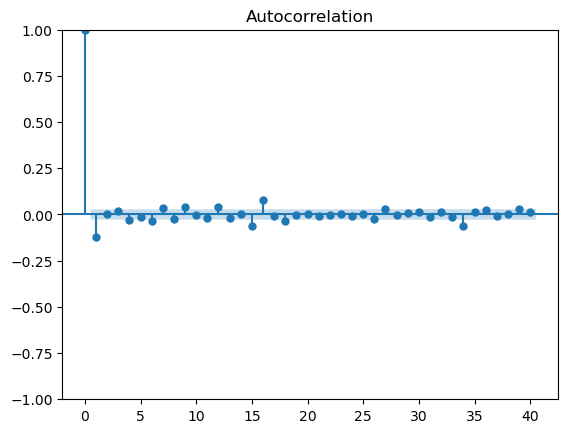

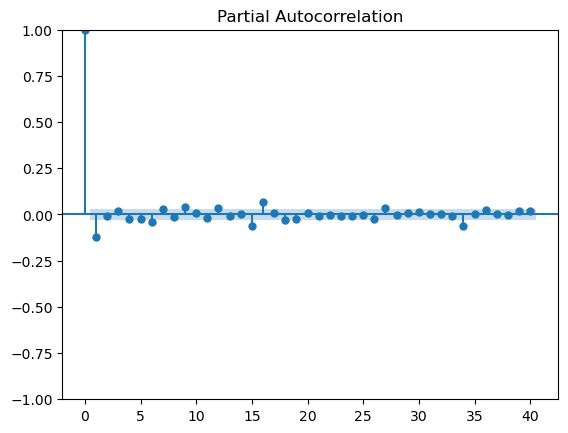

In [12]:
# We plot ACF and PACF for ARIMA order selection 
plot_acf(train[target], lags = 40)
plot_pacf(train[target], lags = 40 );

## ARIMA Order Selection 

ARIMA Models require specification of: 

- p: autoregressor order
- d: differencing order
- q: moving average order

The ACF and PACF confirm the earlier diagnostics. Most autocorrelations lie close to zero, suggesting limited linear dependence in daily log returns.

Given the weak autocorrelation structure and confirmed stationarity, we begin with a simple ARIMA(1,0,1) specification as an initial benchmark.

In [13]:
# Fit ARIMA Static Model 
model = ARIMA(
    train[target],
    order = (1, 0, 1)
)
arima_fit = model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            log_returns   No. Observations:                 5086
Model:                 ARIMA(1, 0, 1)   Log Likelihood               15139.724
Date:                Wed, 24 Jun 2026   AIC                         -30271.448
Time:                        14:52:37   BIC                         -30245.311
Sample:                             0   HQIC                        -30262.295
                               - 5086                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.380      0.168   -9.45e-05       0.001
ar.L1         -0.0566      0.045     -1.252      0.210      -0.145       0.032
ma.L1         -0.0638      0.046     -1.376      0.1

In [14]:
# ARIMA Forecast
arima_forecast = arima_fit.forecast(
    steps = len(test)
)

In [15]:
# Evaluate ARIMA 
arima_results = evaluate_forecast(
    test[target],
    arima_forecast,
    'ARIMA Static'
)

arima_results

,Model,MAE,RMSE,Directional Accuracy
0,ARIMA Static,0.007534,0.010612,0.540094


In [16]:
# Complete the comparison table:
results = pd.concat([
    benchmark_results, 
    arima_results,
], ignore_index = True
    )

results.sort_values('RMSE')

,Model,MAE,RMSE,Directional Accuracy
3,ARIMA Static,0.007534,0.010612,0.540094
0,Historical Mean,0.007534,0.010612,0.539308
2,Zero Return,0.007549,0.010620,0.000000
1,Naive Momentum,0.010901,0.015122,0.500000


In [17]:
# PLot ARIMA results versus benchmarks
comparison['ARIMA Static'] = arima_forecast.values

comparison.iloc[:250].plot(
    title='Forecast Comparison'
)

## Initial ARIMA Results

ARIMA Static produced performance nearly identical to the Historical Mean forecast.

| Model | RMSE |
|---------|---------|
| ARIMA Static | 0.010612 |
| Historical Mean | 0.010612 |
| Zero Return | 0.010620 |
| Naive Momentum | 0.015122 |

This result is consistent with the statistical diagnostics from Notebook 02.

Although daily S&P 500 log returns are stationary, both the ACF and PACF showed very weak autocorrelation. The ARIMA model therefore converges toward the long-run average return rather than extracting a strong predictive signal.

The findings suggest that classical autoregressive models have limited ability to forecast daily market direction. More sophisticated models must demonstrate meaningful improvements over a simple historical mean forecast to justify their additional complexity.

This provides an important benchmark for later phases. More sophisticated models must demonstrate meaningful improvements over a simple historical mean forecast to justify their additional complexity.

# ARIMA Walk-Forward Forecast

### Walk-Forward Validation (Rolling Forecast)

Instead of fitting the model once and forecasting the entire test set, we use a **walk-forward** approach:

- At each time step, the model is retrained using all available data up to that point.
- We forecast only the next day.
- The actual value is then added to the training history.

This method simulates real-world forecasting conditions more realistically than a single static fit, as it allows the model to adapt to new information over time.

In [ ]:
history = train[target].copy()

predictions = []

for t in test.index:

    actual_value = test.loc[t, target]

    model = ARIMA(history, order=(1, 0, 1))
    fitted = model.fit()

    forecast = fitted.forecast(steps=1)

    predictions.append(forecast.iloc[0])

    history = pd.concat([
        history,
        pd.Series([actual_value], index=[t])
    ])

In [ ]:
# Covert it to series
arima_walkforward = pd.Series(
    predictions,
    index = test.index
 )

In [ ]:
# Evaluate ARIMA Walk-Forward
arima_walk_results = evaluate_forecast(
    test[target],
    arima_walkforward,
    'ARIMA Walk-Forward'
)

In [ ]:
# Complete the comparison table:
results = pd.concat([
    results, 
    arima_walk_results,
], ignore_index = True
    )

results.sort_values('RMSE')

,Model,MAE,RMSE,Directional Accuracy
3,ARIMA Static,0.007534,0.010612,0.540094
0,Historical Mean,0.007534,0.010612,0.539308
2,Zero Return,0.007549,0.010620,0.000000
4,ARIMA Walk-Forward,0.007627,0.010663,0.506289
1,Naive Momentum,0.010901,0.015122,0.500000


## ARIMA Evaluation

ARIMA(1,0,1) was evaluated using both a static forecast and an expanding-window walk-forward framework.

Neither approach improved upon the Historical Mean benchmark. RMSE remained effectively unchanged, while directional accuracy stayed close to random chance.

The result is consistent with the earlier diagnostics:

- Weak autocorrelation in daily log returns
- Non-significant AR and MA coefficients
- Limited evidence of short-term return predictability

The forecasting results suggest that daily S&P 500 log returns contain little linear predictive structure. The strongest patterns identified so far remain concentrated in volatility rather than return direction.

# ARIMA residual diagnostics

In [ ]:
residuals = arima_fit.resid

In [ ]:
# Residual Distribution

residuals.plot.hist(
    bins = 50,
    title = 'ARIMA Residual Distribution'
)

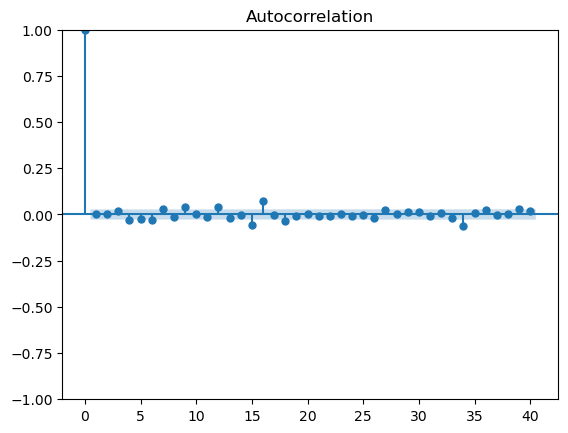

In [ ]:
# Residuals ACF 
plot_acf(residuals, lags = 40);

In [ ]:
# Ljung-Bos test on Residuals 
acorr_ljungbox(
    residuals,
    lags = [10, 20],
    return_df = True
)

,lb_stat,lb_pvalue
10,29.618371,9.887826e-04
20,91.270605,4.440799e-11


In [ ]:
jarque_bera(residuals)

SignificanceResult(statistic=np.float64(26168.92726373899), pvalue=np.float64(0.0))

## ARIMA Residual Diagnostics

The residual ACF shows that most autocorrelations fall within the confidence 
bounds, although several isolated lags remain statistically significant.

The Ljung-Box test rejects independence at both lag 10 (Q = 29.62, p < 0.001) 
and lag 20 (Q = 91.27, p < 0.001). The strengthening statistic at longer lags 
is consistent with volatility clustering rather than a short-term autoregressive 
artefact.

The Jarque-Bera test rejects normality in the residuals (statistic = 26,168.93, 
p ≈ 0), confirming that fat tails persist after fitting ARIMA(1,0,1). The model 
does not remove the distributional non-normality present in the raw log return 
series.

ARIMA(1,0,1) removes part of the linear dependence in the daily log returns but 
does not fully whiten the residuals. The remaining structure is concentrated in 
volatility rather than return direction.

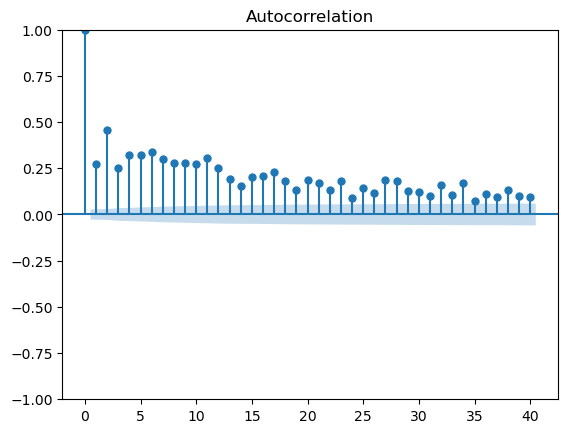

In [ ]:
# Plotting the autocorrelation volatility of the residuals
plot_acf(residuals**2, lags=40);


## Squared residual diagnostics

The ACF of the squared ARIMA residuals shows statistically significant 
autocorrelation across multiple lags, with correlations gradually decaying 
over time. This pattern is characteristic of volatility clustering and confirms 
that variance persistence remains after modelling the conditional mean.

This result is consistent with Notebook 02, where squared log returns exhibited 
substantially stronger autocorrelation than the returns themselves. The structure 
that ARIMA leaves unexplained is in the variance, not the mean — which motivates 
GARCH-family modelling in Notebook 05.

## Why the Engineered Features Were Not Used

Notebook 03 produced a feature set containing lagged returns, rolling statistics, technical indicators, calendar effects, and volatility regime signals.

These features were intentionally excluded from the models in this notebook.

The objective of Notebook 04 is to establish a pure univariate forecasting benchmark using only the historical behaviour of daily S&P 500 log returns. This provides a clean reference point for evaluating whether more sophisticated approaches can add predictive value.

In later notebooks, these engineered features will be introduced as exogenous inputs through machine learning and regression-based forecasting models. Their performance will be evaluated against the classical benchmarks established here.

# SARIMA Model

In [ ]:
# Using Seasonal Period = 5 (trading week)
sarima_model = SARIMAX(
    train[target],
    order = (1, 0, 1),   # Non-Seasonal 
    seasonal_order = (1, 0, 1, 5),   # Seasonal (Weekly)
    enforce_stationarity = False,
    enforce_invertibility = False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       log_returns   No. Observations:                 5086
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 5)   Log Likelihood               15120.082
Date:                           Thu, 18 Jun 2026   AIC                         -30230.164
Time:                                   13:39:34   BIC                         -30197.500
Sample:                                        0   HQIC                        -30218.725
                                          - 5086                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0592      0.046     -1.286      0.198      -0.149       0.031
ma.L1         -0.0607      0.047     -1.296

In [ ]:
# Forecast 
sarima_forecast = sarima_fit.forecast(
    steps = len(test)
)

# Evaluate Results 
sarima_results = evaluate_forecast(
    test[target],
    sarima_forecast,
    'SARIMA(1,0,1)(1,0,1,5)'
)

In [ ]:
# Add Results to results data frame
results = pd.concat(
    [results, sarima_results],
    ignore_index = True
)
results

,Model,MAE,RMSE,Directional Accuracy
0,Historical Mean,0.007534,0.010612,0.539308
1,Naive Momentum,0.010901,0.015122,0.500000
2,Zero Return,0.007549,0.010620,0.000000
3,ARIMA Static,0.007534,0.010612,0.540094
4,ARIMA Walk-Forward,0.007627,0.010663,0.506289
5,"SARIMA(1,0,1)(1,0,1,5)",0.007549,0.010620,0.474843


## SARIMA Evaluation

A SARIMA(1,0,1)(1,0,1,5) model was tested to assess whether weekly seasonality (5 trading days) could improve forecasting performance.

### Key Results

- Seasonal AR(5) coefficient: p-value = **0.406**
- Seasonal MA(5) coefficient: p-value = **0.356**
- AIC increased from **-30271.45** (ARIMA) to **-30230.16** (SARIMA)

### Interpretation

Notebook 02 identified some calendar effects, including stronger average log returns on Tuesdays and Wednesdays and weaker performance in September. However, the seasonal terms in the SARIMA model were not statistically significant, and the additional complexity did not improve model fit.

This suggests that any weekly seasonality present in the data is weak relative to the overall noise in daily log returns.

### Conclusion

Adding a weekly seasonal component did not improve the model. The simpler ARIMA(1,0,1) specification remains preferable based on both statistical significance and AIC.

The calendar effects observed during exploratory analysis may be better represented through explicit calendar features rather than a seasonal ARIMA structure.

# Prophet Model

In [ ]:
# Prophet requires columns ds and y 
prophet_train = train[[target]].reset_index()

prophet_train.columns = ['ds', 'y']

prophet_train.head()

,ds,y
0,2001-02-13,-0.008690
1,2001-02-14,-0.002186
2,2001-02-15,0.008091
3,2001-02-16,-0.019086
4,2001-02-20,-0.017509


In [ ]:
prophet_model = Prophet(
    daily_seasonality = False,
    weekly_seasonality = True,
    yearly_seasonality= True
    )

prophet_model.fit(prophet_train)

13:39:35 - cmdstanpy - INFO - Chain [1] start processing
13:39:36 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# Create Future dates
# We use trading days as market doesn't trade on weekends
future = prophet_model.make_future_dataframe(
    periods = len(test),
    freq = 'B'
)


In [ ]:
# Forecast
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = (
    prophet_forecast_full['yhat']
    .iloc[-len(test):]
    .values
)


In [ ]:
# Evaluate Results 
prophet_results = evaluate_forecast(
    test[target],
    prophet_forecast,
    'Prophet'
)

prophet_results

,Model,MAE,RMSE,Directional Accuracy
0,Prophet,0.007569,0.010662,0.522013


In [ ]:
# Add Prophet Results to the comparison table 
results = pd.concat(
    [results, prophet_results],
    ignore_index = True
)

results.sort_values('RMSE')

,Model,MAE,RMSE,Directional Accuracy
3,ARIMA Static,0.007534,0.010612,0.540094
0,Historical Mean,0.007534,0.010612,0.539308
5,"SARIMA(1,0,1)(1,0,1,5)",0.007549,0.010620,0.474843
2,Zero Return,0.007549,0.010620,0.000000
6,Prophet,0.007569,0.010662,0.522013
4,ARIMA Walk-Forward,0.007627,0.010663,0.506289
1,Naive Momentum,0.010901,0.015122,0.500000


## Prophet evaluation

Prophet was included as a benchmark because it is widely used for forecasting 
problems involving trend and seasonality.
RMSE came in at 0.010662, 
MAE at 0.007569,
and directional accuracy at 52.20% — none of which improved on the 
Historical Mean.

This outcome is consistent with the characteristics of daily S&P 500 log returns 
identified in Notebook 02. Unlike business metrics such as revenue, demand, or 
website traffic, daily returns contain little persistent trend structure and weak 
seasonality. Prophet is designed to model smooth trends and recurring seasonal 
patterns — daily financial returns are largely dominated by noise and short-lived 
shocks, which limits the structure available for it to capture.

# Notebook 04 Conclusions

This notebook evaluated several classical time series models to establish forecasting benchmarks for daily S&P 500 log returns.

## Model Comparison Summary

| Model                  |         RMSE |          MAE | Directional Accuracy |
| ---------------------- | -----------: | -----------: | -------------------: |
| Historical Mean        | **0.010612** | **0.007534** |           **53.93%** |
| ARIMA Static           | **0.010612** | **0.007534** |           **54.01%** |
| SARIMA(1,0,1)(1,0,1,5) | **0.010620** | **0.007549** |           **47.48%** |
| Zero Return            | **0.010620** | **0.007549** |            **0.00%** |
| Prophet                | **0.010662** | **0.007569** |           **52.20%** |
| ARIMA Walk-Forward     | **0.010663** | **0.007627** |           **50.63%** |
| Naive Momentum         | **0.015122** | **0.010901** |           **50.00%** |

### Key Result

None of the classical models (ARIMA, SARIMA, or Prophet) meaningfully outperformed the Historical Mean benchmark.

## Main Findings

* ARIMA(1,0,1) captured only limited linear structure and failed to improve forecast accuracy relative to simple benchmarks.
* SARIMA with weekly seasonality (period = 5) produced insignificant seasonal coefficients and no forecasting improvement.
* Prophet was unable to extract useful trend or seasonal signals beyond what simpler benchmark models achieved.
* The Historical Mean forecast performed as well as, or better than, substantially more complex models.

These outcomes are consistent with the statistical diagnostics from Notebook 02, which showed weak directional autocorrelation and limited predictability in daily log returns.

## Residual Analysis

Ljung-Box tests rejected independence at lag 10 (Q = 29.62, p < 0.001) and lag 20 (Q = 91.27, p < 0.001), with the statistic strengthening at longer lags. The Jarque-Bera test rejected normality in the residuals (statistic = 26,168.93, p ≈ 0), confirming that fat tails persist after modelling the conditional mean. The ACF of squared residuals showed gradual decay across 40 lags, consistent with volatility clustering.

## Final Takeaway

The evidence from this notebook suggests that daily S&P 500 log returns contain very limited predictable structure in their conditional mean.

None of the classical forecasting models meaningfully outperformed the Historical Mean benchmark, despite increasing model complexity.

The Ljung-Box tests remained significant at higher lags, the Jarque-Bera statistic confirmed substantial departures from normality, and the ACF of squared residuals revealed persistent volatility clustering.

These results indicate that while return direction is difficult to predict, market risk is not randomly distributed through time.

The remaining structure is concentrated in conditional variance rather than conditional mean — which shifts the focus from forecasting market direction to forecasting market risk, and motivates GARCH-family modelling in Notebook 05.